In [5]:
%pip install kagglehub pandas matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 68 kB 5.9 MB/s eta 0:00:011
     |████████████████████████████████| 10.8 MB 9.8 MB/s eta 0:00:01
     |████████████████████████████████| 7.8 MB 15.4 MB/s eta 0:00:01
     |████████████████████████████████| 294 kB 68.9 MB/s eta 0:00:01
     |████████████████████████████████| 78 kB 36.9 MB/s eta 0:00:01
     |████████████████████████████████| 64 kB 18.7 MB/s eta 0:00:01
     |████████████████████████████████| 174 kB 33.5 MB/s eta 0:00:01
     |████████████████████████████████| 349 kB 61.3 MB/s eta 0:00:01
     |████████████████████████████████| 5.3 MB 35.9 MB/s eta 0:00:01
     |████████████████████████████████| 510 kB 80.9 MB/s eta 0:00:01
     |████████████████████████████████| 2.9 MB 104.8 MB/s eta 0:00:01
     |████████████████████████████████| 4.7 MB 3.8 MB/s eta 0:00:01
     |████████████████████████████████| 122 kB 46.5 MB/s eta 0:00:01
     |██████████████████████

In [6]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual para las gráficas
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Librerías importadas correctamente.")

/Users/santiagosantafe/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/santiagosantafe/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Matplotlib is building the font cache; this may take a moment.


Librerías importadas correctamente.


In [7]:
# Definición del repositorio en Kaggle
dataset_repo = "olistbr/brazilian-ecommerce"

# Carga de las tablas que componen el módulo transaccional (PostgreSQL) y catálogo (MongoDB)
print("Descargando y cargando datasets desde Kaggle...")

df_orders = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS, dataset_repo, "olist_orders_dataset.csv"
)

df_payments = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS, dataset_repo, "olist_order_payments_dataset.csv"
)

df_products = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS, dataset_repo, "olist_products_dataset.csv"
)

df_reviews = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS, dataset_repo, "olist_order_reviews_dataset.csv"
)

print("\n--- ¡Carga Exitosa! ---")
print(f"Total de Órdenes: {df_orders.shape[0]}")
print(f"Total de Pagos: {df_payments.shape[0]}")
print(f"Total de Productos: {df_products.shape[0]}")
print(f"Total de Reseñas: {df_reviews.shape[0]}")

Descargando y cargando datasets desde Kaggle...


/var/folders/29/rd5l587j4zx89_z60vw9y_jm0000gn/T/ipykernel_24776/777995429.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_orders = kagglehub.load_dataset(


100%|██████████| 6.75M/6.75M [00:00<00:00, 11.4MB/s]

Extracting zip of olist_orders_dataset.csv...



/var/folders/29/rd5l587j4zx89_z60vw9y_jm0000gn/T/ipykernel_24776/777995429.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_payments = kagglehub.load_dataset(


...

Extracting zip of olist_products_dataset.csv...



/var/folders/29/rd5l587j4zx89_z60vw9y_jm0000gn/T/ipykernel_24776/777995429.py:19: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_reviews = kagglehub.load_dataset(


100%|██████████| 6.42M/6.42M [00:00<00:00, 11.2MB/s]

Extracting zip of olist_order_reviews_dataset.csv...



--- ¡Carga Exitosa! ---
Total de Órdenes: 99441
Total de Pagos: 103886
Total de Productos: 32951
Total de Reseñas: 99224


Muestra de la tabla Payments (Validando relación de Múltiples Pagos por Orden):


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45



Cantidad de registros que usan pago dividido (secuencial > 1): 4526


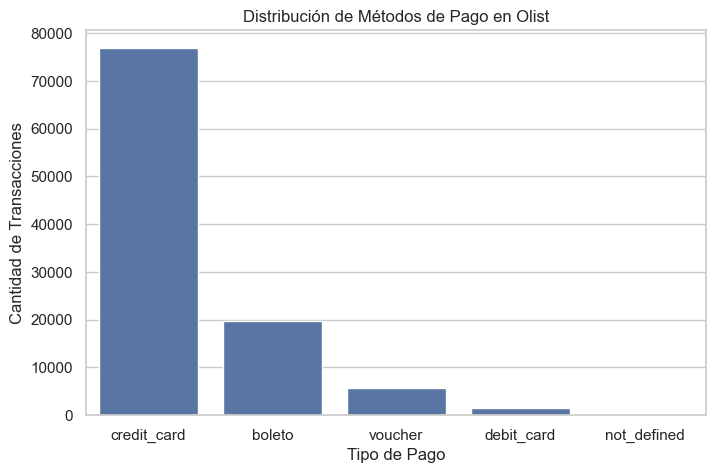

In [8]:
# Visualización de los primeros registros de pagos para entender la cardinalidad (1:N)
print("Muestra de la tabla Payments (Validando relación de Múltiples Pagos por Orden):")
display(df_payments.head())

# Verificamos si una misma orden tiene múltiples pagos (payment_sequential > 1)
multi_payment_orders = df_payments[df_payments['payment_sequential'] > 1]
print(f"\nCantidad de registros que usan pago dividido (secuencial > 1): {multi_payment_orders.shape[0]}")

# Distribución de Tipos de Pago
plt.figure(figsize=(8, 5))
sns.countplot(data=df_payments, x='payment_type', order=df_payments['payment_type'].value_counts().index)
plt.title("Distribución de Métodos de Pago en Olist")
plt.ylabel("Cantidad de Transacciones")
plt.xlabel("Tipo de Pago")
plt.show()

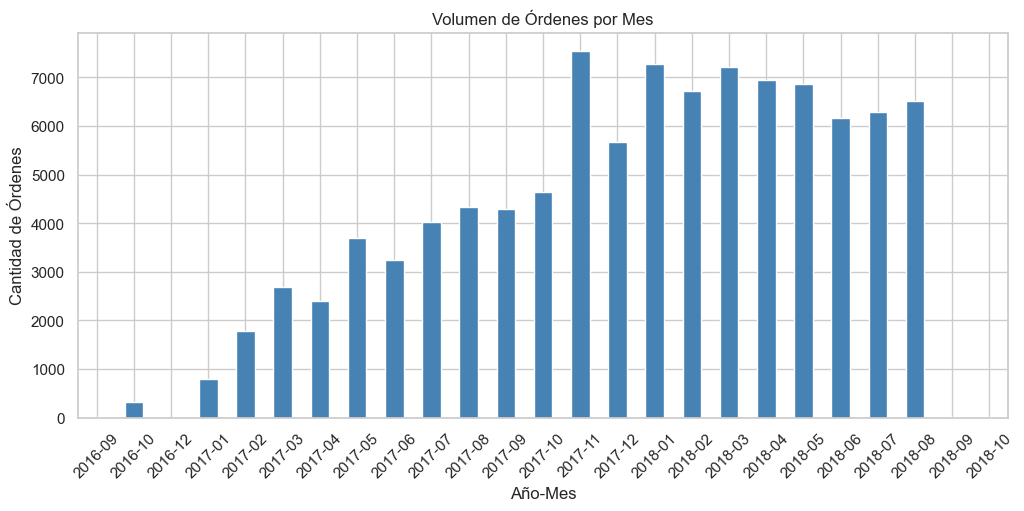

Nota: Este crecimiento y volumen mensual justifica la creación de particiones (orders_YYYY_mMM) para no saturar el índice primario.


In [11]:
# Convertimos el string a datetime para analizar el volumen por año/mes
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])

# Agrupamos por Año-Mes
df_orders['year_month'] = df_orders['order_purchase_timestamp'].dt.to_period('M')
orders_by_month = df_orders.groupby('year_month').size()

plt.figure(figsize=(12, 5))
orders_by_month.plot(kind='bar', color='steelblue')
plt.title("Volumen de Órdenes por Mes")
plt.ylabel("Cantidad de Órdenes")
plt.xlabel("Año-Mes")
plt.xticks(rotation=45)
plt.show()

print("Nota: Este crecimiento y volumen mensual justifica la creación de particiones (orders_YYYY_mMM) para no saturar el índice primario.")

Valores nulos en atributos específicos de productos:


product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


Nota Arquitectónica:
La variabilidad de atributos (algunos productos no tienen fotos, otros no tienen peso/dimensiones)
y la gran cantidad de categorías, hacen de MongoDB y el uso del 'Attribute Pattern' la opción ideal.


/var/folders/29/rd5l587j4zx89_z60vw9y_jm0000gn/T/ipykernel_24776/962485892.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_reviews, x='review_score', palette="viridis")


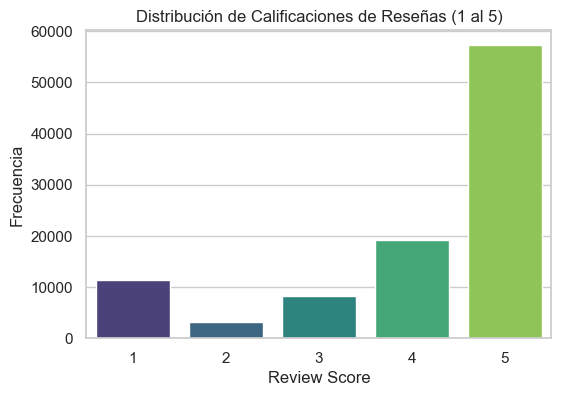

In [10]:
# Visualización de variables en Productos para justificar MongoDB (NoSQL)
print("Valores nulos en atributos específicos de productos:")
null_stats = df_products.isnull().sum()
display(null_stats[null_stats > 0])

print("\nNota Arquitectónica:")
print("La variabilidad de atributos (algunos productos no tienen fotos, otros no tienen peso/dimensiones)")
print("y la gran cantidad de categorías, hacen de MongoDB y el uso del 'Attribute Pattern' la opción ideal.")

# Exploración rápida de los scores de Reseñas
plt.figure(figsize=(6, 4))
sns.countplot(data=df_reviews, x='review_score', palette="viridis")
plt.title("Distribución de Calificaciones de Reseñas (1 al 5)")
plt.ylabel("Frecuencia")
plt.xlabel("Review Score")
plt.show()